# <p style="text-align: center; color: #FF00FF;">Proiect – Rețele neuronale artificiale (MLP). CLASIFICARE </p>
### <p style="text-align: right; color:  #FF00FF;">Iliescu Daria-Gabriela, 1333a</p>

In [73]:
# Importarea bibliotecilor
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### **<span style="color:  #FF00FF">1. Explorarea inițială a datelor (EDA) </span>**

In [74]:
# Citirea fișierul CSV
df = pd.read_csv('fake_job_postings.csv')

In [75]:
# Verificarea primelor 5 rânduri pentru a confirma încărcarea corectă
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [76]:
df.shape

(17880, 18)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [78]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


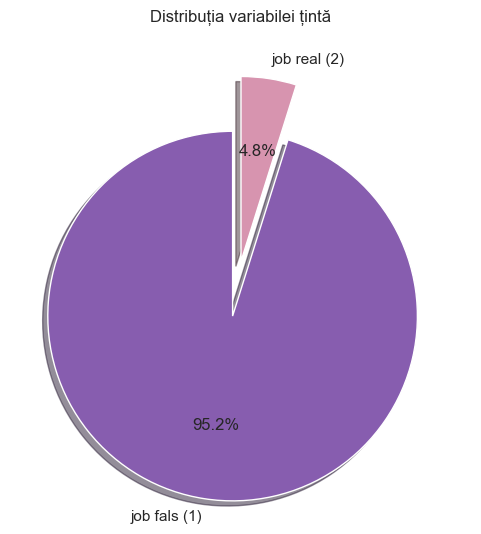

In [79]:
counts = df['fraudulent'].value_counts()
labels = counts.index
sizes = counts.values

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=['job fals (1)','job real (2)'],
    explode=[0.3,0], 
    colors=[ '#875DAF', '#D794AF'],
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)
plt.title('Distribuția variabilei țintă')
plt.show()

In [80]:
# Eliminarea coloanelor irelevante

df = df.drop(['department','salary_range','benefits','title','location'], axis=1)

In [81]:
# Selectarea coloanelor numerice 
numerical = df.select_dtypes(include=['number']).columns.tolist()

# Selectarea coloanele categorice (de tip obiect) 
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Afișarea rezultatelor
print('Coloane numerice:', numerical)
print('Coloane categorice:', categorical)

Coloane numerice: ['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
Coloane categorice: ['company_profile', 'description', 'requirements', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']


In [82]:
# Transformarea coloanelor categorice în variabile 'dummy'
df = pd.get_dummies(
    df,
    columns=['employment_type', 'required_experience','required_education','industry','function'],   # coloanele categoriale relevante
    drop_first=True                # evităm colinearitatea
)

# Verificarea primelor 5 rânduri
df.head()

,job_id,company_profile,description,requirements,telecommuting,has_company_logo,has_questions,fraudulent,employment_type_Full-time,employment_type_Other,...,function_Public Relations,function_Purchasing,function_Quality Assurance,function_Research,function_Sales,function_Science,function_Strategy/Planning,function_Supply Chain,function_Training,function_Writing/Editing
0,1,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,0,1,0,0,False,True,...,False,False,False,False,False,False,False,False,False,False
1,2,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,0,1,0,0,True,False,...,False,False,False,False,False,False,False,False,False,False
2,3,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,0,1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",0,1,0,0,True,False,...,False,False,False,False,True,False,False,False,False,False
4,5,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,0,1,1,0,True,False,...,False,False,False,False,False,False,False,False,False,False


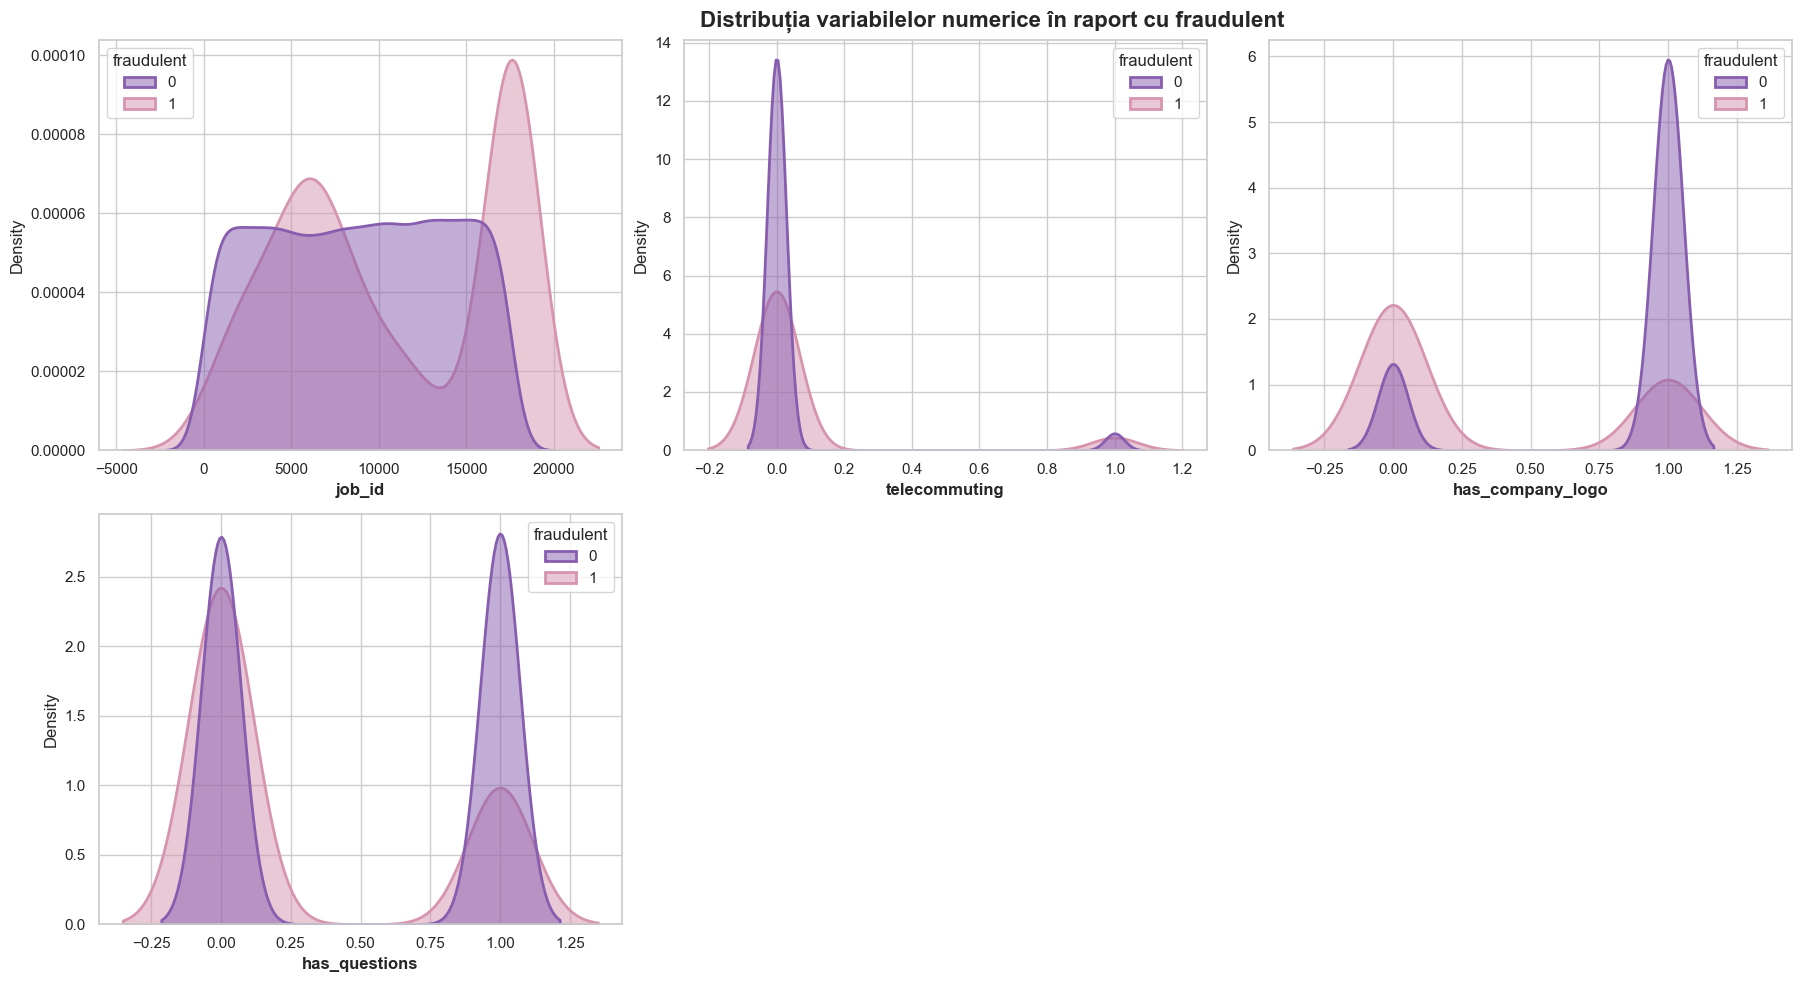

In [83]:
sns.set(style="whitegrid")

# Selectăm toate coloanele numerice
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop('fraudulent')  # scoatem targetul

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        x=col, 
        data=df, 
        hue='fraudulent', 
        fill=True,
        palette=['#875DAF', '#D794AF'], 
        alpha=0.5, 
        lw=2, 
        ax=axes[i],
        common_norm=False
    )
    axes[i].set_xlabel(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=12)

# Eliminăm axele goale
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribuția variabilelor numerice în raport cu fraudulent', fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95, right=0.9)
plt.show()
